#Library Imports:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
!pip install h5py

In [5]:
import h5py

#Part A. Question 1. Data import and Understanding

In [6]:
#A - Read the ‘Signals.csv’ as DatFrame and import required libraries.
signals_df = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/8.Intro to Neural Networks/Week31_Project Submission/NN Project Data - Signal.csv')
signals_df.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
print(signals_df.shape)

(1599, 12)


In [8]:
#B - Check for missing values and print percentage for each attribute.
missing_values = signals_df.isnull().sum()
total_values = signals_df.shape[0]
missing_percentages = (missing_values / total_values) * 100
print("Missing Value Percentages:")
for col, perc in missing_percentages.items():
  print(f"{col}: {missing_values[col]} missing ({perc:.2f}%)")

Missing Value Percentages:
Parameter 1: 0 missing (0.00%)
Parameter 2: 0 missing (0.00%)
Parameter 3: 0 missing (0.00%)
Parameter 4: 0 missing (0.00%)
Parameter 5: 0 missing (0.00%)
Parameter 6: 0 missing (0.00%)
Parameter 7: 0 missing (0.00%)
Parameter 8: 0 missing (0.00%)
Parameter 9: 0 missing (0.00%)
Parameter 10: 0 missing (0.00%)
Parameter 11: 0 missing (0.00%)
Signal_Strength: 0 missing (0.00%)


In [9]:
#C - Check for presence of duplicate records in the dataset and impute with appropriate method.
duplicate_count = signals_df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 240


In [10]:
signals_df.drop_duplicates(inplace=True)
signals_df.shape

(1359, 12)

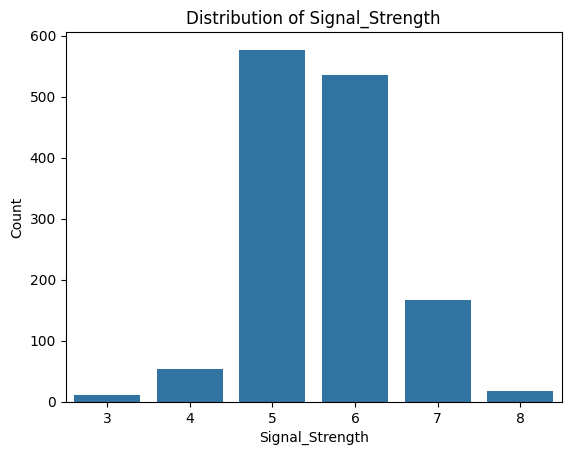

In [11]:
#D - Visualise distribution of the target variable.
sns.countplot(x='Signal_Strength', data=signals_df)
plt.xlabel('Signal_Strength')
plt.ylabel('Count')
plt.title('Distribution of Signal_Strength')
plt.show()

In [12]:
#E - Share insights from the initial data analysis (at least 2).

**Insights:**
1. No null value for the data set.
2. There are 240 duplicate records.
3. Target variable 'Signal_Strength' is not balanced.

#Part A. Question 2 Data preprocessing

In [13]:
#A - Split the data into X & Y.
X = signals_df.drop('Signal_Strength', axis=1)
Y = signals_df['Signal_Strength']

In [14]:
#B - Split the data into train & test with 70:30 proportion.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [15]:
#C - Print shape of all the 4 variables and verify if train and test data is in sync.
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (951, 11)
Shape of X_test: (408, 11)
Shape of Y_train: (951,)
Shape of Y_test: (408,)


Based on the above data we can say that train and test data is in sync

In [16]:
#D - Normalise the train and test data with appropriate method.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#E - Transform Labels into format acceptable by Neural Network
Y_train_encoded = tf.keras.utils.to_categorical(Y_train, num_classes=10)
Y_test_encoded = tf.keras.utils.to_categorical(Y_test, num_classes=10)

#Part A. Question 3 Model Training & Evaluation using Neural Network

In [18]:
#A - Design a Neural Network to train a classifier.
model = Sequential()
model.add(Dense(128, input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [28]:
#B - Train the classifier using previously designed Architecture
history = model.fit(X_train_scaled, Y_train_encoded, epochs=50, batch_size=32, validation_data=(X_test_scaled, Y_test_encoded))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5688 - loss: 0.2970 - val_accuracy: 0.5343 - val_loss: 0.2930
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5800 - loss: 0.2905 - val_accuracy: 0.5368 - val_loss: 0.2857
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5701 - loss: 0.2869 - val_accuracy: 0.5417 - val_loss: 0.2789
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5426 - loss: 0.2834 - val_accuracy: 0.5515 - val_loss: 0.2726
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5755 - loss: 0.2726 - val_accuracy: 0.5515 - val_loss: 0.2667
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5515 - loss: 0.2668 - val_accuracy: 0.5490 - val_loss: 0.2613
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5537 - loss: 0.2653 - val_accuracy: 0.5515 - val_loss: 0.2563
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5660 - loss: 0.2592 - val_accuracy: 0.5515 - val_lo

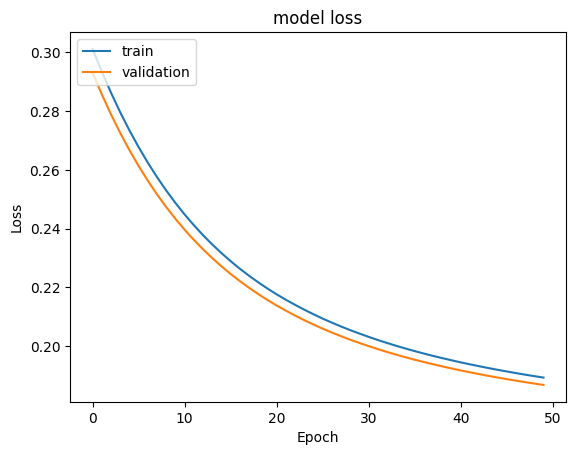

In [29]:
#C - Plot 2 separate visuals.
#i. Training Loss and Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

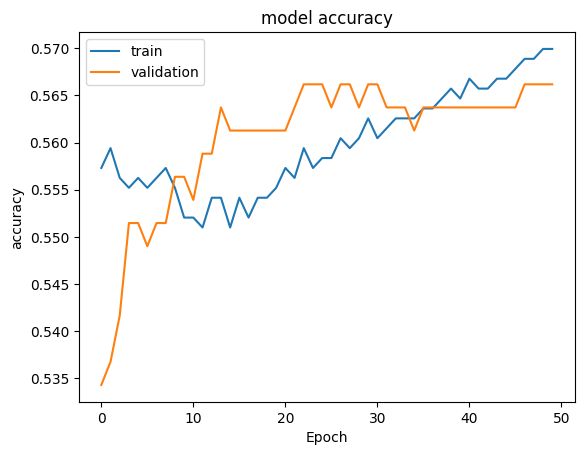

In [30]:
#ii. Training Accuracy and Validation Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [40]:
#D - Design new architecture/update existing architecture in attempt to improve the performance of the model.
model1 = Sequential()
model1.add(Dense(128, input_shape=(X_train_scaled.shape[1],), kernel_initializer='he_normal'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dropout(0.5))
model1.add(Dense(64, kernel_initializer='he_normal'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dropout(0.4))
model1.add(Dense(32, kernel_initializer='he_normal'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [42]:
history1 = model1.fit(X_train_scaled, Y_train_encoded, epochs=50, batch_size=32, validation_data=(X_test_scaled, Y_test_encoded))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.0640 - loss: 0.7145 - val_accuracy: 0.1520 - val_loss: 0.5735
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1405 - loss: 0.5619 - val_accuracy: 0.3456 - val_loss: 0.5269
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2636 - loss: 0.4563 - val_accuracy: 0.4510 - val_loss: 0.4863
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4177 - loss: 0.3758 - val_accuracy: 0.5123 - val_loss: 0.4404
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4351 - loss: 0.3211 - val_accuracy: 0.5294 - val_loss: 0.3884
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5046 - loss: 0.2777 - val_accuracy: 0.5392 - val_loss: 0.3445
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5243 - loss: 0.2509 - val_accuracy: 0.5588 - val_loss: 0.3016
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5614 - loss: 0.2314 - val_accuracy: 0.5588 - val_loss

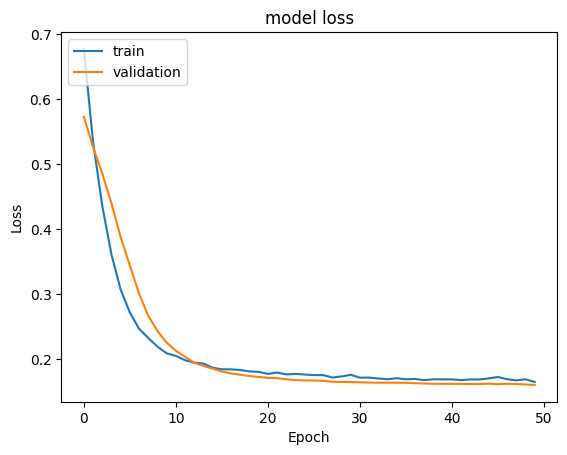

In [43]:
#E - Plot visuals as in Q3.C and share insights about difference observed in both the models.
#i. Training Loss and Validation Loss
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

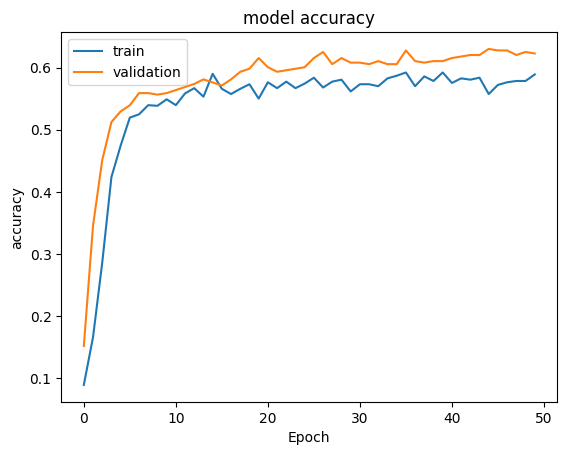

In [44]:
#ii. Training Accuracy and Validation Accuracy
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Insights:**
1. Model performance is good as Validation accuracy is always better than the training accuracy but in previous model it was fliping between two.
2. Train and validation loss decreased and thenflaten as oppose to previous model train loss and validation loss decreased consistently.
3. Train and validation accuracy incresed consistently and then flaten as compare to previous model was fliping between two.

#Part B. Question 1 Data Import and Exploration

In [85]:
#A - Read the .h5 file and assign to a variable.
vehicles_df = h5py.File('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/8.Intro to Neural Networks/Week31_Project Submission/Autonomous_Vehicles_SVHN_single_grey1.h5', 'r')

In [86]:
#B - Print all the keys from the .h5 file.
vehicles_df.keys()

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>

In [87]:
#C - Split the data into X_train, X_test, Y_train, Y_test
X_train = vehicles_df['X_train'][:]
X_test = vehicles_df['X_test'][:]
y_train = vehicles_df['y_train'][:]
y_test = vehicles_df['y_test'][:]
X_val = vehicles_df['X_val'][:]
y_val = vehicles_df['y_val'][:]

#Part B. Question 2 Data Visualisation and preprocessing

In [88]:
#A - Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (42000, 32, 32)
Shape of X_test: (18000, 32, 32)
Shape of y_train: (42000,)
Shape of y_test: (18000,)
Shape of X_val: (60000, 32, 32)
Shape of y_val: (60000,)


As per the above observation Train and Test data is in sync with the X and y.

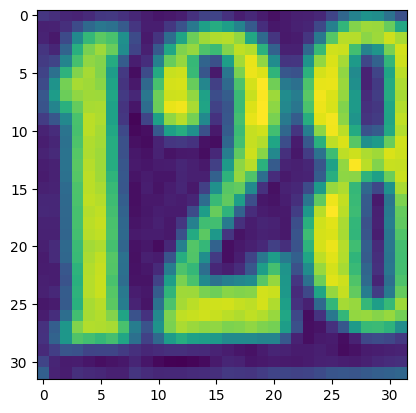

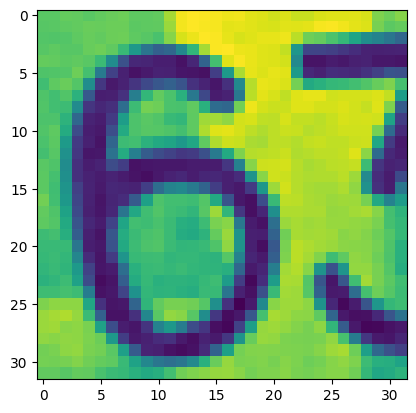

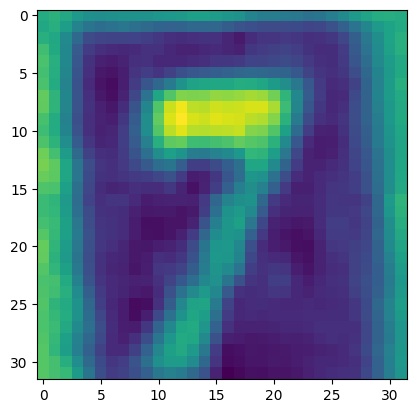

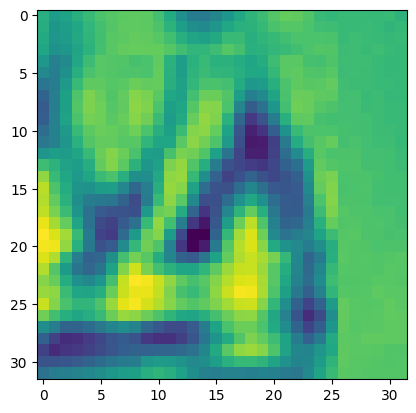

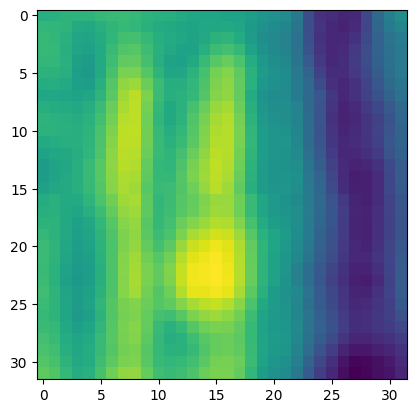

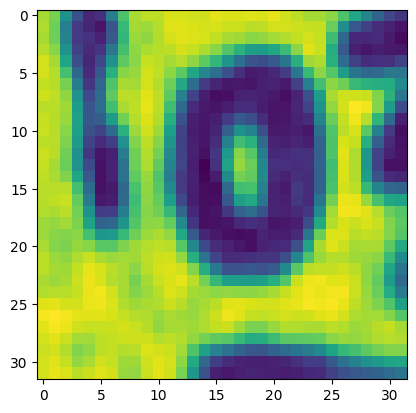

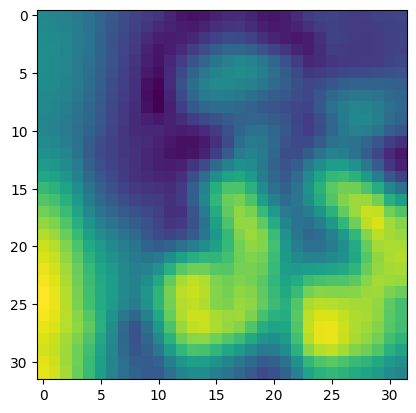

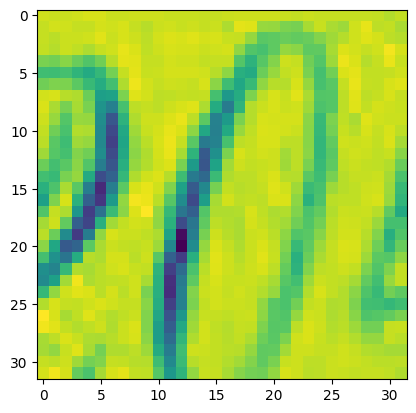

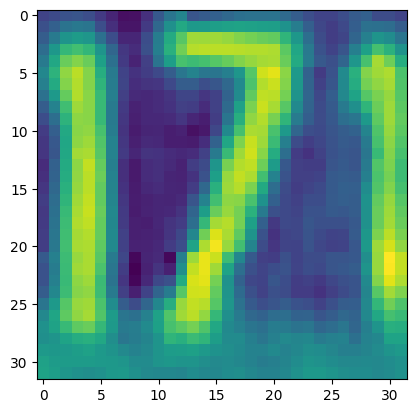

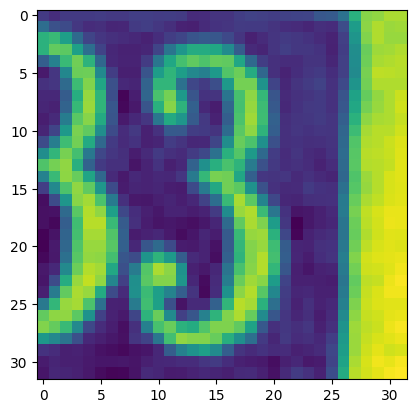

In [89]:
#B - Visualise first 10 images in train data and print its corresponding labels.
for i in range(10):
    image = X_train[i]
    plt.figure(i)
    plt.imshow(image)

In [90]:
#C -Reshape all the images with appropriate shape update the data in same variable.
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(42000, 1024) (18000, 1024) (42000,) (18000,)


In [91]:
#D - Normalise the images i.e. Normalise the pixel values.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [92]:
#E - Transform Labels into format acceptable by Neural Network
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [93]:
#F - Print total Number of classes in the Dataset.
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_train.shape[1]

(42000, 1024) (18000, 1024) (42000, 10) (18000, 10)


10

#Part B. Question 3 Model Training & Evaluation using Neural Network

In [99]:
#A - Design a Neural Network to train a classifier.
model = Sequential()
model.add(Dense(128, activation='relu',kernel_initializer='he_uniform', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(64, activation='relu',kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Dense(y_train.shape[1], activation='softmax'))

In [100]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [101]:
#B - Train the classifier using previously designed Architecture (Use best suitable parameters).
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2915 - loss: 2.0347 - val_accuracy: 0.1339 - val_loss: 3.2193
Epoch 2/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5777 - loss: 1.3231 - val_accuracy: 0.5876 - val_loss: 1.2987
Epoch 3/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6336 - loss: 1.1634 - val_accuracy: 0.5517 - val_loss: 1.4376
Epoch 4/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6624 - loss: 1.0711 - val_accuracy: 0.6622 - val_loss: 1.0855
Epoch 5/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6790 - loss: 1.0208 - val_accuracy: 0.6163 - val_loss: 1.2176
Epoch 6/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6853 - loss: 0.9962 - val_accuracy: 0.6953 - val_loss: 0.9702
Epoch 7/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7097 - loss: 0.9347 - val_accuracy: 0.6740 - val_loss: 1.0060
Epoch 8/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7140 - loss: 0.9188 -

In [105]:
#C - Evaluate performance of the model with appropriate metrics.
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)
print(classification_report(y_test, y_pred))

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1814
           1       0.75      0.82      0.79      1828
           2       0.80      0.77      0.79      1803
           3       0.83      0.64      0.73      1719
           4       0.78      0.84      0.81      1812
           5       0.78      0.74      0.76      1768
           6       0.68      0.82      0.75      1832
           7       0.83      0.76      0.79      1808
           8       0.66      0.75      0.70      1812
           9       0.82      0.71      0.76      1804

    accuracy                           0.77     18000
   macro avg       0.78      0.77      0.77     18000
weighted avg       0.77      0.77      0.77     18000



In [102]:
#D - Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.
epochs = range(1, len(history.history['loss']) + 1)
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

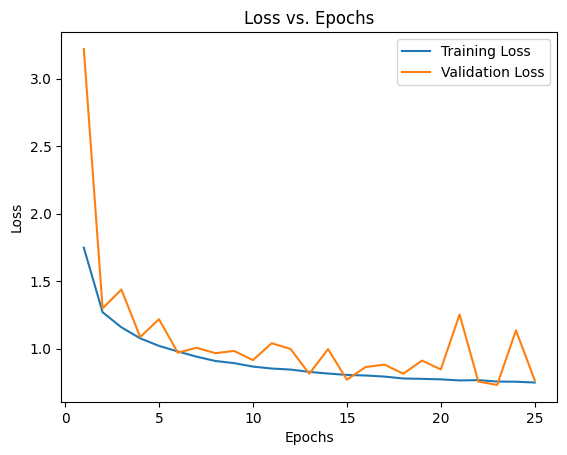

In [103]:
# Plotting Training and Validation Loss
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

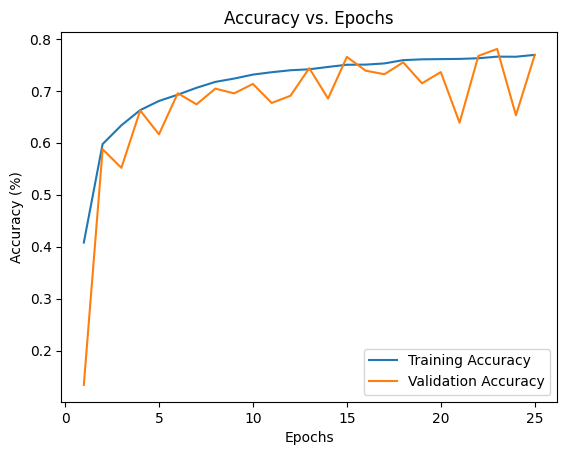

In [104]:
# Plotting Training and Validation Accuracy
plt.plot(epochs, training_accuracy, label='Training Accuracy')
plt.plot(epochs, validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

**Observations:**
1. Train loss is decreasing continously but validation loss decreasing with fluctuation.
2. Train accuracy is increasing smoothly but validation accuracy increses with fluctuation.
3. There is similar accuracy for both tarin and validation so it can be assumed to be a generalised model.